In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import pickle

ACCENT  = "#38bdf8"   # sky-blue
ACCENT2 = "#f472b6"   # pink
ACCENT3 = "#34d399"   # emerald
ACCENT4 = "#fb923c"   # orange
PALETTE = [ACCENT, ACCENT2, ACCENT3, ACCENT4, "#a78bfa", "#fbbf24"]

In [ ]:
X_train = pd.read_csv("../data/preprocessed/X_train.csv")
X_test = pd.read_csv("../data/preprocessed/X_test.csv")
y_train = pd.read_csv("../data/preprocessed/y_train.csv")
y_test = pd.read_csv("../data/preprocessed/y_test.csv")

In [1]:
import pickle

with open('../models/cap_values.pkl', 'rb') as f:
    cap_values = pickle.load(f)

## Feature Scaling

In [ ]:
robust_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
target_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

preprocessor = ColumnTransformer(
    transformers=[
        ('Scaling',  RobustScaler(),  robust_cols),
        ('Encoding', TargetEncoder(), target_cols),
    ]
)

X_train_trans = preprocessor.fit_transform(X_train, y_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)

X_test_trans = preprocessor.transform(X_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_train.columns)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
X_test_trans.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,0.066667,0.139355,0.583249,0.000000,0.0,0.0,-0.615385,0.072928,0.100364,0.086245,0.118043,0.0771,0.068128,0.041116,0.066808,0.092231
1,0.333333,-0.053825,0.106730,0.000000,0.0,0.0,1.076923,0.109263,0.100364,0.106730,0.118043,0.0771,0.126338,0.041116,0.066808,0.092231
2,-0.533333,-0.070046,0.209872,1.000000,0.0,0.0,0.307692,0.089015,0.100364,0.106730,0.118043,0.0771,0.126338,0.041116,0.104086,0.092231
3,-0.200000,0.150415,-0.144133,0.736966,0.0,0.0,0.538462,0.072928,0.100364,0.086245,0.118043,0.0771,0.126338,0.041116,0.066808,0.092231
4,-0.333333,1.083871,-0.955891,-0.584963,0.0,0.0,-0.923077,0.089015,0.150089,0.106730,0.118043,0.0771,0.126338,0.148347,0.167917,0.092231


## Handling Imbalanced Data using SMOTE
**SMOTE** (Synthetic Minority Over-sampling Technique) generates *new synthetic*  
minority-class samples by interpolating between real minority samples and their  
k-nearest neighbours — avoiding simple duplication.

In [ ]:
models = {
    "Decision Tree"     : DecisionTreeClassifier(),
    "Random Forest"     : RandomForestClassifier(n_jobs=-1),
    "Gradient Boosting" : GradientBoostingClassifier(),
}

# Wrap each model in a SMOTE → model pipeline
pipelines = {
    name: ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])
    for name, model in models.items()
}

## Hyperparameter Tuning

In [ ]:
param_grids = {
    "Decision Tree": {
        "clf__max_depth"        : [5, 10, 15, None],
        "clf__min_samples_leaf" : [1, 5, 10],
        "clf__criterion"        : ["gini", "entropy"],
    },
    "Random Forest": {
        "clf__n_estimators"     : [100, 200],
        "clf__max_depth"        : [10, 20, None],
        "clf__min_samples_leaf" : [1, 5],
    },
    "Gradient Boosting": {
        "clf__n_estimators"  : [100, 200],
        "clf__learning_rate" : [0.05, 0.1, 0.2],
        "clf__max_depth"     : [3, 5],
    },
}

In [ ]:
tuned_models  = {}
tuned_results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, pipeline in pipelines.items():
    print(f"\n  Tuning: {name}", flush=True)

    r_search = RandomizedSearchCV(
        estimator  = pipeline,
        param_distributions = param_grids[name],
        cv         = cv,
        scoring    = "roc_auc",
        n_jobs     = 1,
        verbose    = 1
    )
    r_search.fit(X_train_trans, y_train)

    tuned_models[name]  = r_search.best_estimator_
    tuned_results[name] = {
        "best_params" : r_search.best_params_,
        "best_cv_auc" : r_search.best_score_,
    }
    print(f"    Best params : {r_search.best_params_}")
    print(f"    Best CV AUC : {r_search.best_score_:.4f}")


  Tuning: Decision Tree
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    Best params : {'clf__min_samples_leaf': 10, 'clf__max_depth': 10, 'clf__criterion': 'gini'}
    Best CV AUC : 0.8750

  Tuning: Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

    Best params : {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_depth': None}
    Best CV AUC : 0.9248

  Tuning: Gradient Boosting
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

    Best params : {'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
    Best CV AUC : 0.9293


## Model Training


Decision Tree  Best threshold: 0.50
   Best F1       : 0.5388
   Precision     : 0.4217
   Recall        : 0.7457

Random Forest  Best threshold: 0.80
   Best F1       : 0.6026
   Precision     : 0.5499
   Recall        : 0.6664

Gradient Boosting  Best threshold: 0.96
   Best F1       : 0.6015
   Precision     : 0.5075
   Recall        : 0.7382


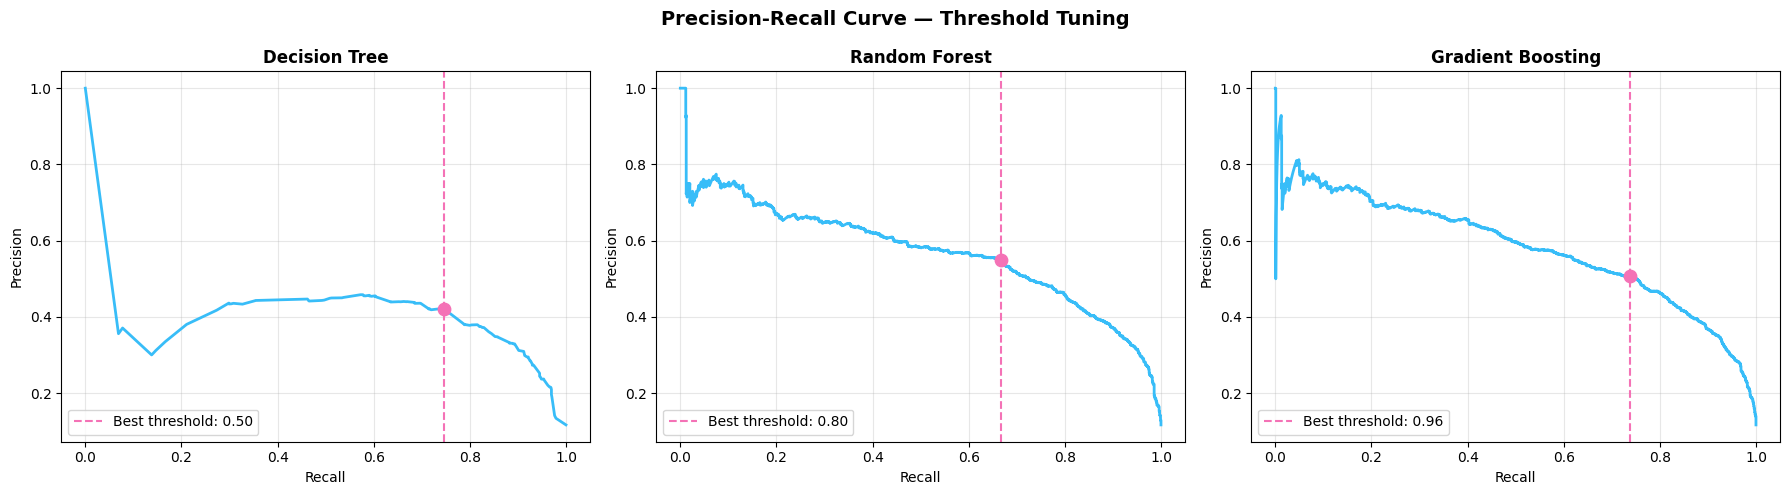

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Curve — Threshold Tuning", fontsize=14, fontweight="bold")

best_thresholds = {}

for i, (name, pipeline) in enumerate(tuned_models.items()):
    y_prob = pipeline.predict_proba(X_test_trans)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

    # Find threshold with best F1
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx  = f1_scores.argmax()
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh

    axes[i].plot(recalls, precisions, color=ACCENT, linewidth=2)
    axes[i].axvline(recalls[best_idx],    color=ACCENT2, linestyle='--', label=f"Best threshold: {best_thresh:.2f}")
    axes[i].scatter(recalls[best_idx], precisions[best_idx], color=ACCENT2, zorder=5, s=80)
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

    print(f"\n{name}  Best threshold: {best_thresh:.2f}")
    print(f"   Best F1       : {f1_scores[best_idx]:.4f}")
    print(f"   Precision     : {precisions[best_idx]:.4f}")
    print(f"   Recall        : {recalls[best_idx]:.4f}")

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Results After Threshold Tuning ---")

for name, pipeline in tuned_models.items():
    y_prob      = pipeline.predict_proba(X_test_trans)[:, 1]
    best_thresh = best_thresholds[name]

    # Apply custom threshold instead of default 0.5
    y_pred_tuned = (y_prob >= best_thresh).astype(int)

    print(f"\n{'='*55}")
    print(f"  {name}  (threshold = {best_thresh:.2f})")
    print(f"{'='*55}")
    print(f"  F1        : {f1_score(y_test, y_pred_tuned):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred_tuned):.4f}")
    print(classification_report(y_test, y_pred_tuned))


--- Results After Threshold Tuning ---

  Decision Tree  (threshold = 0.50)
  F1        : 0.5388
  Recall    : 0.7457
  Precision : 0.4217
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      7985
           1       0.42      0.75      0.54      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.81      0.72      9043
weighted avg       0.90      0.85      0.87      9043


  Random Forest  (threshold = 0.80)
  F1        : 0.6026
  Recall    : 0.6664
  Precision : 0.5499
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.55      0.67      0.60      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.80      0.77      9043
weighted avg       0.91      0.90      0.90      9043


  Gradient Boosting  (threshold = 0.96)
  F1        : 0.6015
  Recall    : 0.7382
  Precision : 0.5075
  

In [ ]:
best_name     = "Gradient Boosting"
best_pipeline = tuned_models[best_name]
best_thresh   = best_thresholds[best_name]

y_prob       = best_pipeline.predict_proba(X_test_trans)[:, 1]
y_pred_final = (y_prob >= best_thresh).astype(int)

print(f"Best Model    : {best_name}")
print(f"Threshold     : {best_thresh:.2f}")
print(f"F1            : {f1_score(y_test, y_pred_final):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

Best Model    : Gradient Boosting
Threshold     : 0.96
F1            : 0.6015
Recall        : 0.7382
Precision     : 0.5075
ROC-AUC       : 0.9186
PR-AUC        : 0.5803

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      7985
           1       0.51      0.74      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.82      0.77      9043
weighted avg       0.91      0.89      0.89      9043



In [ ]:
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump({
        'model'     : best_pipeline,
        'threshold' : best_thresh,
        'name'      : best_name,
        'preprocessor' : preprocessor,
        'cap_values'   : cap_values
    }, f)

print("Model saved to best_model.pkl")

Model saved to best_model.pkl
